In [5]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import textgrids
from pathlib import Path
import re

import os
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

In [6]:
def get_words(txt_dir, align_type="words"):
    tg_files = list(Path(txt_dir).rglob("*.TextGrid"))
    text = []

    for tg_path in tg_files:
        tg = textgrids.TextGrid(str(tg_path))
        tier = tg[align_type]

        for interval in tier:
            label = interval.text.strip().lower()
            if label in ["", "<unk>", "sp", "sil", "spn"]:
                continue
            #  remove numbers and decimals
            label = re.sub(r'\d+', '', label)
            text.append(label)
    
    if align_type == "phones":
        text = [re.sub(r'\d+', '', phn) for phn in text]

    return text

def get_clusters(partition_path):
    clusters = []
    current_cluster = []
    
    with open(partition_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            
            if len(parts) == 3:
                current_cluster.append(tuple(parts))
            
            elif len(parts) == 2 and current_cluster:
                clusters.append(current_cluster)
                current_cluster = [] 
                
        if current_cluster:
            clusters.append(current_cluster)

    return clusters

In [7]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 7,
})

def get_color(stem):
    if "cosine" in stem:
        return "tab:blue"
    elif "kmeans" in stem:
        return "tab:gray"
    elif "birch" in stem:
        return "tab:green"
    elif "agglomerative" in stem:
        return "tab:orange"
    elif "fbgmm" in stem:
        return "tab:cyan"
    else:
        return "tab:green"
    
def basic_method_label(stem):
    stem = stem.lower()
    if "kmeans" in stem:
        return "K-means"
    elif "birch" in stem:
        return "BIRCH"
    elif "agglomerative" in stem:
        return "Agglomerative"
    elif "cosine" in stem or "graph" in stem:
        return "Graph"
    elif "fbgmm" in stem:
        return "FBGMM"
    else:
        return None
    
def extract_threshold(path):
    if "t0" in path.stem:
        threshold = f'0{path.stem.split("t0")[1].split("_")[0]}'
        threshold = float(threshold)
    else:
        threshold = np.inf
    return float(threshold)

def extract_resolution(path):
    if "r" in path.stem:
        resolution = f'0{path.stem.split("r0")[1].split("_")[0]}'
        resolution = float(resolution)
    else:
        resolution = np.inf
    return float(resolution)

LINESTYLE = {
    "K-means":      "--",
    "BIRCH":        "--",
    "FBGMM":        "--",
    "Agglomerative": "-",
    "Graph":         "-",
}


### dev-clean words: K-means vs Gold

Saving figures to: figures/LibriSpeech/dev-clean


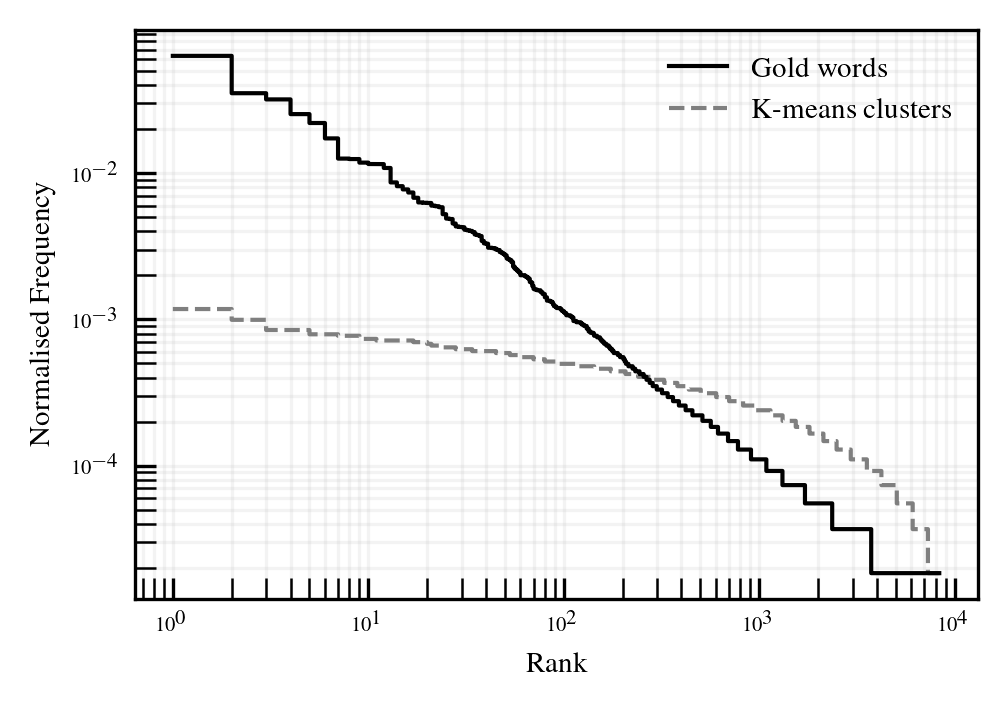

In [9]:

dataset_dir = Path("data/alignments/LibriSpeech/dev-clean_feature_sliced/")
kmeans_path = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/fig/kmeans_k8372_269.82.txt")

gt_items = get_words(dataset_dir, align_type="words")
kmeans_clusters = get_clusters(kmeans_path)

dataset = kmeans_path.parts[1]
dataset_subset = kmeans_path.parts[2].split("_")[0]
fig_dir = Path("figures") / dataset / dataset_subset
fig_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving figures to: {fig_dir}")

legend_handles = {}
fig, ax = plt.subplots(figsize=(3.4, 2.4), dpi=300)

# Ground truth distribution
gt_counts = Counter(gt_items)
gt_freqs = np.array(sorted(gt_counts.values(), reverse=True))
gt_probs = gt_freqs / gt_freqs.sum()
gt_ranks = np.arange(1, len(gt_probs) + 1)

line, = ax.loglog(
    gt_ranks,
    gt_probs,
    linestyle="-",
    color="black",
    linewidth=1,
    drawstyle="steps-post",
    label="Ground truth",
    zorder=3,
)
legend_handles.setdefault("Gold words", line)

global_max_freq = gt_probs[0]
global_max_rank = len(gt_probs)

# K-means
cluster_sizes = np.array(sorted([len(c) for c in kmeans_clusters], reverse=True))
probs = cluster_sizes / cluster_sizes.sum()
ranks = np.arange(1, len(probs) + 1)

line, = ax.loglog(
        ranks,
        probs,
        label="K-means clusters",
        color='tab:gray',
        linewidth=1,
        drawstyle="steps-post",
        linestyle="--",
    )

legend_handles.setdefault("K-means clusters", line)  

ax.set_xlabel("Rank")
ax.set_ylabel("Normalised Frequency")

global_max_freq = max(global_max_freq, probs[0])
global_max_rank = max(global_max_rank, len(probs))

ax.grid(True, which="both", ls="-", alpha=0.15)
ax.tick_params(direction="in", which="both", length=5)

legend_order = ["Gold words", "K-means clusters"]
ax.legend(
    [legend_handles[label] for label in legend_order if label in legend_handles],
    [label for label in legend_order if label in legend_handles],
    loc="upper right",
    frameon=False,
)
plt.tight_layout()
plt.savefig(
    fig_dir / "zipf:kmeans_vs_gold_words.pdf",
    bbox_inches="tight",
)
plt.show()

### dev-clean: words vs syllables vs unsupervised syllabic segments

Saving figures to: figures/LibriSpeech/dev-clean


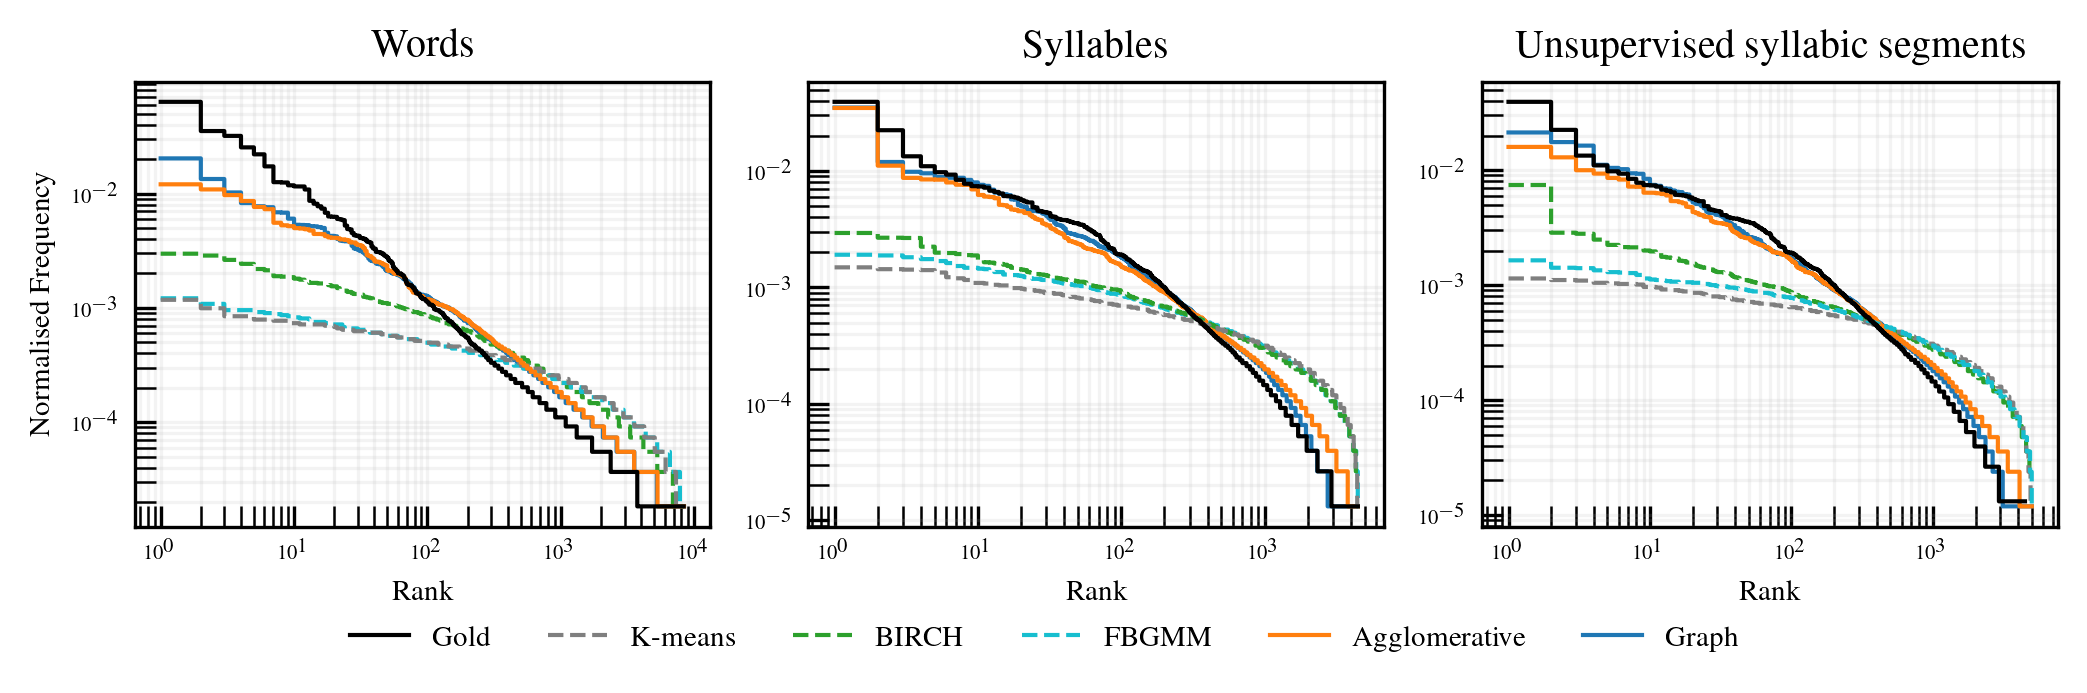

In [11]:
words_partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/fig")
syllables_partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/syllables/fig")
syllabic_segments_partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/norm-prom-seg/prominence_0.35_window_3/k5_000")

dataset_dir = Path("data/alignments/LibriSpeech/dev-clean_feature_sliced/")
gt_words = get_words(dataset_dir, align_type="words")
gt_syllables = get_words(dataset_dir, align_type="syllables")
gt_syllabic_segments = get_words(dataset_dir, align_type="syllables")

dataset = dataset_dir.parts[2]
dataset_subset = dataset_dir.parts[3].split("_")[0]
fig_dir = Path("figures") / dataset / dataset_subset
fig_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving figures to: {fig_dir}")

partition_dirs = [
    words_partition_dir,
    syllables_partition_dir,
    syllabic_segments_partition_dir,
]

gt_words_list = [
    gt_words,
    gt_syllables,
    gt_syllabic_segments,
]

subplot_titles = [
    "Words",
    "Syllables",
    "Unsupervised syllabic segments",
]

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.4), dpi=300, sharey=False)
legend_handles = {}
n_samples = 20

for ax, partition_dir, gt_items, title in zip(
    axes, partition_dirs, gt_words_list, subplot_titles
):
    paths = sorted(partition_dir.glob("*.txt"), key=extract_threshold)

    # Ground truth
    gt_counts = Counter(gt_items)
    gt_freqs = np.array(sorted(gt_counts.values(), reverse=True))
    gt_probs = gt_freqs / gt_freqs.sum()
    gt_ranks = np.arange(1, len(gt_probs) + 1)

    line, = ax.loglog(
        gt_ranks,
        gt_probs,
        linestyle="-",
        color="black",
        linewidth=1,
        drawstyle="steps-post",
        label="Ground truth",
        zorder=3,
    )
    legend_handles.setdefault("Gold", line)

    global_max_freq = gt_probs[0]
    global_max_rank = len(gt_probs)

    # Partitions
    for path in paths:
        if "knn" in path.stem or "edit" in path.stem:
            continue

        label = basic_method_label(path.stem)
        if label is None:
            continue

        clusters = get_clusters(path)
        cluster_sizes = np.array(sorted([len(c) for c in clusters], reverse=True))
        probs = cluster_sizes / cluster_sizes.sum()
        ranks = np.arange(1, len(probs) + 1)


        line, = ax.loglog(
            ranks,
            probs,
            label=label,
            color={
                "K-means": "tab:gray",
                "Agglomerative": "tab:orange",
                "Graph": "tab:blue",
                "BIRCH": "tab:green",
                "FBGMM": "tab:cyan",
            }[label],
            linestyle=LINESTYLE[label],  
            linewidth=1,
            drawstyle="steps-post",
        )

        legend_handles.setdefault(label, line)

        global_max_freq = max(global_max_freq, probs[0])
        global_max_rank = max(global_max_rank, len(probs))

    
    ax.set_title(title)
    ax.set_xlabel("Rank")
    ax.grid(True, which="both", ls="-", alpha=0.15)
    ax.tick_params(direction="in", which="both", length=5)

axes[0].set_ylabel("Normalised Frequency")

legend_order = ["Gold", "K-means","BIRCH", "FBGMM", "Agglomerative", "Graph"]

fig.legend(
    [legend_handles[label] for label in legend_order if label in legend_handles],
    [label for label in legend_order if label in legend_handles],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05), 
    ncol=6,
    frameon=False,
)
plt.tight_layout(rect=[0, 0.1, 1, 1.0])
plt.savefig(
    fig_dir / "zipf:words_vs_syllables_vs_syllabic.pdf",
    bbox_inches="tight",
)
plt.show()

### dev-clean words: graph $\tau$ vs. $\gamma$

Saving figures to: figures/LibriSpeech/dev-clean


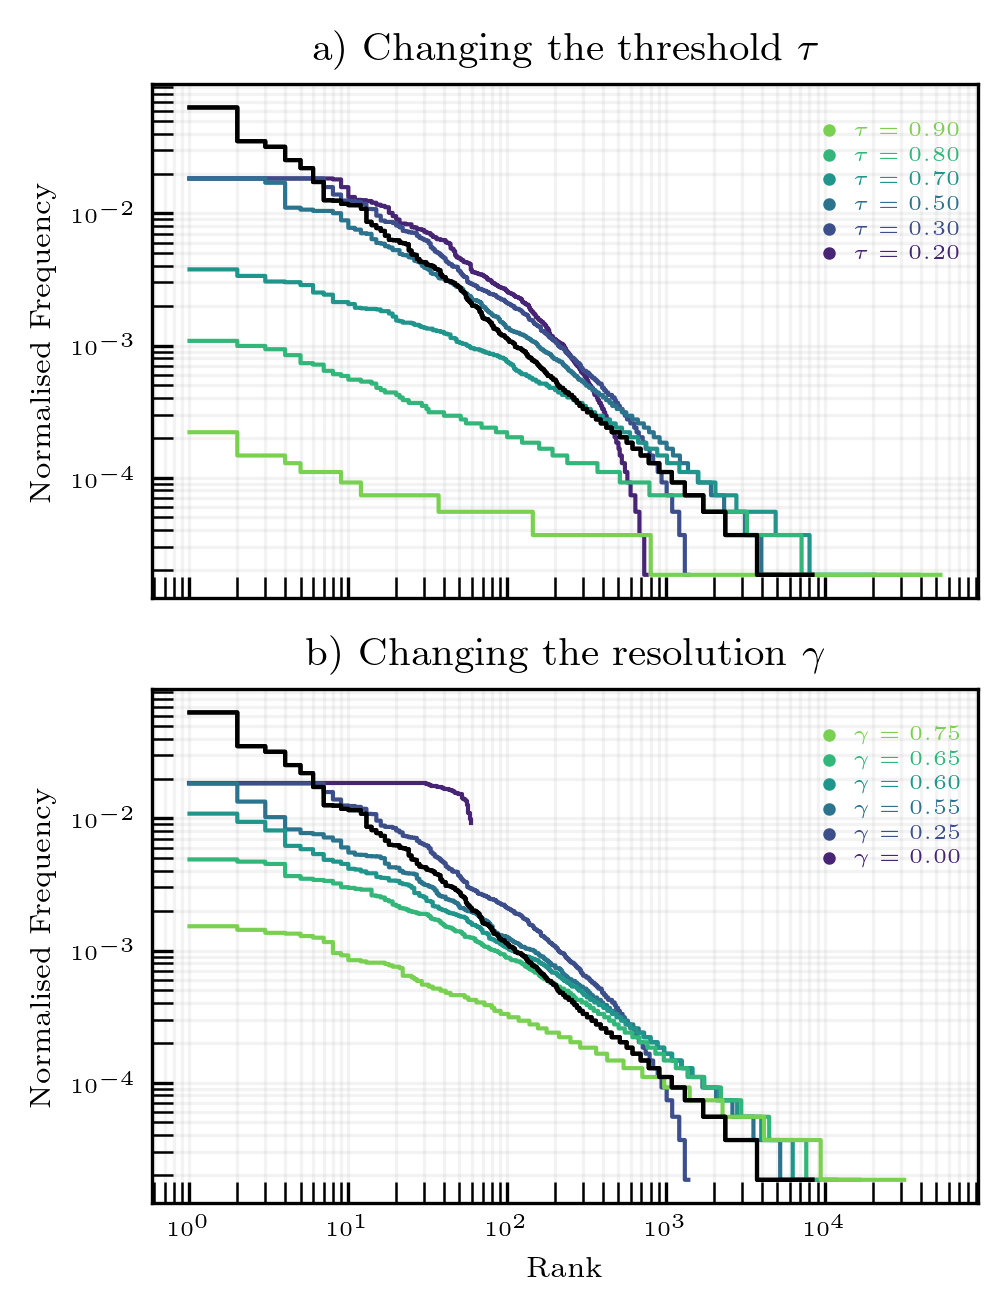

In [50]:
tau_partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/r0.25")
gamma_partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/t0.7")

dataset_dir = Path("data/alignments/LibriSpeech/dev-clean_feature_sliced/")
gt_words = get_words(dataset_dir, align_type="words")

dataset = dataset_dir.parts[2]
dataset_subset = dataset_dir.parts[3].split("_")[0]
fig_dir = Path("figures") / dataset / dataset_subset
fig_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving figures to: {fig_dir}")

plot_configs = [
    {
        "partition_dir": tau_partition_dir,
        "title": r"a) Changing the threshold $\tau$",
        "parameter_name": "tau",
    },
    {
        "partition_dir": gamma_partition_dir,
        "title": r"b) Changing the resolution $\gamma$",
        "parameter_name": "gamma",
    },
]

fig, axes = plt.subplots(
    2, 1,
    figsize=(3.4, 4.8),
    dpi=300,
    sharex=True,
    sharey=True
)

legend_handles = {}

# Gold distribution
gt_counts = Counter(gt_items)
gt_freqs = np.array(sorted(gt_counts.values(), reverse=True))
gt_probs = gt_freqs / gt_freqs.sum()
gt_ranks = np.arange(1, len(gt_probs) + 1)

for ax, config in zip(axes, plot_configs):
    labels = []

    partition_dir = config["partition_dir"]
    title = config["title"]
    parameter_name = config["parameter_name"]

    # Gold line
    line, = ax.loglog(
        gt_ranks,
        gt_probs,
        linestyle="-",
        color="black",
        linewidth=1,
        drawstyle="steps-post",
        label="Gold",
        zorder=3,
    )
    legend_handles.setdefault("Gold", line)

    if parameter_name == "tau":
        path_values = [
            (path, 1 - extract_threshold(path))  # displayed tau value
            for path in partition_dir.glob("*.txt")
        ]
    else:
        path_values = [
            (path, extract_resolution(path))     # displayed gamma value
            for path in partition_dir.glob("*.txt")
        ]

    path_values = sorted(path_values, key=lambda x: x[1])  # low -> high

    cmap = plt.get_cmap("viridis")
    colors = cmap(np.linspace(0.10, 0.8, len(path_values)))

    line, = ax.loglog(
        gt_ranks,
        gt_probs,
        linestyle="-",
        color="black",
        linewidth=1,
        drawstyle="steps-post",
        label="Gold distribution",
        zorder=3,
    )
    legend_handles.setdefault("Gold distribution", line)

    labels = []

    for (path, value), color in zip(path_values, colors):

        clusters = get_clusters(path)
        cluster_sizes = np.array(sorted([len(c) for c in clusters], reverse=True))
        probs = cluster_sizes / cluster_sizes.sum()
        ranks = np.arange(1, len(probs) + 1)

        if parameter_name == "tau":
            label_text = rf"$\tau={value:.2f}$"
        else:
            label_text = rf"$\gamma={value:.2f}$"

        line, = ax.loglog(
            ranks,
            probs,
            color=color,
            linewidth=1,
            drawstyle="steps-post",
            label="Graph",
        )

        legend_handles.setdefault("Graph", line)
        labels.append((value, label_text, color))

    labels = sorted(labels, key=lambda x: x[0], reverse=True)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    log_xmin = np.log10(xmin)
    log_xmax = np.log10(xmax)

    x_label_pos = 10 ** (log_xmin + 0.85 * (log_xmax - log_xmin))
    x_marker_pos = 10 ** (log_xmin + 0.82 * (log_xmax - log_xmin))
    y_start = ymax * 0.45
    y_factor = 0.65

    for _, label_text, color in labels:
        ax.plot(
            x_marker_pos,
            y_start,
            marker="o",
            markersize=2,
            color=color,
            clip_on=False,
        )
        ax.text(
            x_label_pos,
            y_start,
            label_text,
            fontsize=5,
            color=color,
            ha="left",
            va="center",
            clip_on=False,
        )
        y_start *= y_factor

    ax.set_title(title)
    ax.set_ylabel("Normalised Frequency")
    ax.grid(True, which="both", ls="-", alpha=0.15)
    ax.tick_params(direction="in", which="both", length=5)

axes[-1].set_xlabel("Rank")

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(
    fig_dir / "zipf:tau_vs_gamma.pdf",
    bbox_inches="tight",
)
plt.show()

### dev-clean words: K-means vs Agglomerative vs Graph

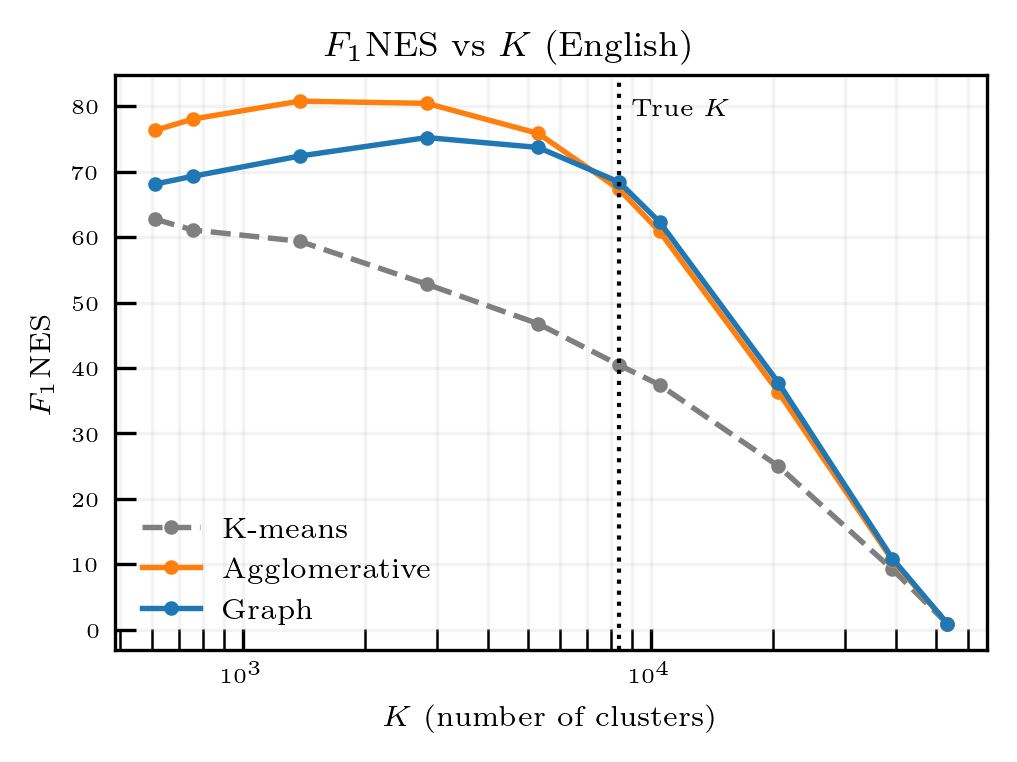

In [8]:
thresholds = [0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
clusters = [610, 755, 1_381, 2_830, 5_302, 8_372, 10_521, 20_563, 39_166, 53_392]
f1_graph = [68.12, 69.31, 72.41, 75.23, 73.72, 68.43, 62.33, 37.79, 10.87, 0.94]
f1_kmeans = [62.76, 61.11, 59.38, 52.82, 46.78, 40.47, 37.43, 25.02, 9.22, 0.91]
f1_agglom = [76.33, 78.06, 80.80, 80.46, 75.87, 67.32, 60.89, 36.34, 10.60, 0.95]

fig, ax = plt.subplots(figsize=(3.4, 2.4), dpi=300)

ax.plot(
    clusters, f1_kmeans,
    marker="o",
    markersize=2.5,
    linewidth=1.3,
    color="tab:gray",
    label="K-means",
    linestyle="--",
)

ax.plot(
    clusters, f1_agglom,
    marker="o",
    markersize=2.5,
    linewidth=1.3,
    color="tab:orange",
    label="Agglomerative",
)

ax.plot(
    clusters, f1_graph,
    marker="o",
    markersize=2.5,
    linewidth=1.3,
    color="tab:blue",
    label="Graph",
)

ax.axvline(x=8_372, color="black", linestyle=":", linewidth=1.0, alpha=1.0)
ax.text(9000, 0.93,  r"True $K$", ha="left", fontsize=6,
        transform=ax.get_xaxis_transform())

ax.set_xscale("log")
ax.set_xlabel(r"$K$ (number of clusters)")
ax.set_ylabel(r"$F_1$NES")

ax.grid(True, which="both", ls="-", alpha=0.15)
ax.tick_params(direction="in", which="both", length=5)

ax.legend(frameon=False, loc="best")

fig.tight_layout()
fig.suptitle("$F_1$NES vs $K$ (English)", y=1.02)
fig.savefig("figures/f1_vs_k_log_scale.pdf", bbox_inches="tight")
plt.show()

### dev-clean words: \tau vs iNES and NES

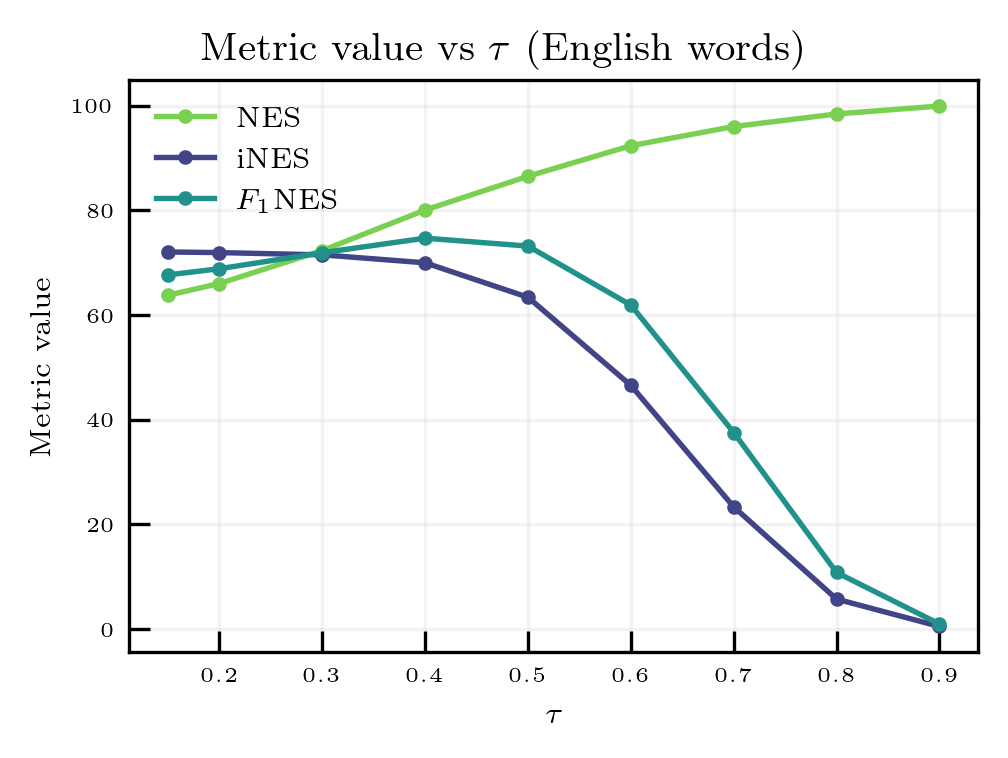

In [49]:
thresholds = [0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# clusters = [610, 755, 1_381, 2_830, 5_302, 10_521, 20_563, 39_166, 53_392]
nes_vals = [63.77, 66.00, 72.30, 80.05, 86.50, 92.34, 96.00, 98.40, 99.92]
ines_vals = [72.03, 71.91, 71.48, 69.96, 63.37, 46.53, 23.32, 5.70, 0.47]
f1_nes = [67.65, 68.83, 71.89, 74.67, 73.15, 61.88, 37.53, 10.78, 0.94]

fig, ax = plt.subplots(figsize=(3.4, 2.4), dpi=300)
color_map = plt.get_cmap("viridis")
ax.plot(
    thresholds, nes_vals,
    marker="o",
    markersize=2.5,
    linewidth=1.3,
    color=color_map(0.8),
    label="NES",
)
ax.plot(
    thresholds, ines_vals,
    marker="o",
    markersize=2.5,
    linewidth=1.3,
    color=color_map(0.2),
    label="iNES",
)
ax.plot(
    thresholds, f1_nes,
    marker="o",
    markersize=2.5,
    linewidth=1.3,
    color=color_map(0.5),
    label="$F_1$NES",
)

# ax.axvline(x=8_372, color="black", linestyle=":", linewidth=1.0, alpha=1.0)
# ax.text(9000, 0.93,  r"True $K$ ($\tau$=0.7)", ha="left", fontsize=6,
#         transform=ax.get_xaxis_transform())

# ax.set_xscale("log")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"Metric value")

ax.grid(True, which="both", ls="-", alpha=0.15)
ax.tick_params(direction="in", which="both", length=5)

ax.legend(frameon=False, loc="best")

fig.tight_layout()
fig.suptitle(r"Metric value vs $\tau$ (English words)", y=1.02)
fig.savefig("figures/tau_vs_NES.pdf", bbox_inches="tight")
plt.show()

### other languages: K-means vs Agglomerative vs Graph

Saving figures to: figures


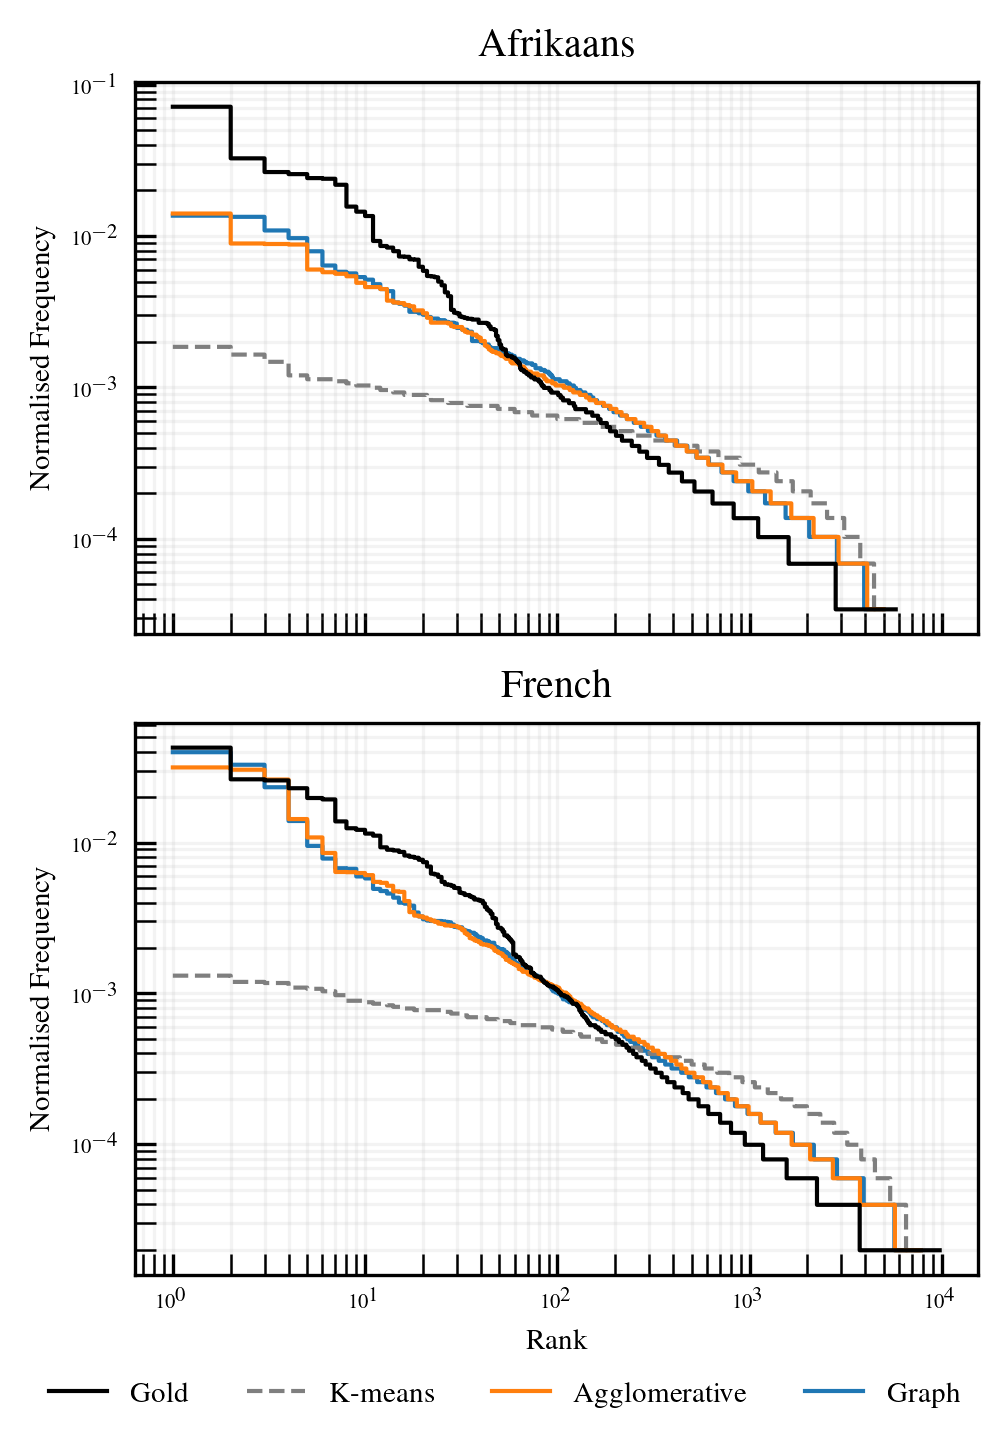

In [12]:
language_configs = [
    {
        "title": "Afrikaans",
        "partition_dir": Path("outputs/Fleurs/afrikaans_feature_sliced/wavlm_large/layer_21/gt/words/fig"),
        "dataset_dir": Path("data/alignments/Fleurs/afrikaans_sliced_with_syllables/"),
        "align_type": "words",
    },
    {
        "title": "French",
        "partition_dir": Path("outputs/zerospeech/french_subset2/wavlm_large/layer_21/gt/words/fig"),
        "dataset_dir": Path("data/alignments/zerospeech/french_feature_sliced_with_syllables_subset2_with_syllables/"),
        "align_type": "words",
    },
]

fig_dir = Path("figures/")
fig_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving figures to: {fig_dir}")

fig, axes = plt.subplots(
    2, 1,
    figsize=(3.4, 4.8),
    dpi=300,
    sharex=True,
    sharey=False,
)

legend_handles = {}

for ax, config in zip(axes, language_configs):

    partition_dir = config["partition_dir"]
    gt_words = get_words(config["dataset_dir"], align_type=config["align_type"])

    paths = sorted(partition_dir.glob("*.txt"), key=extract_threshold)

    # Gold distribution
    gt_counts = Counter(gt_words)
    gt_freqs = np.array(sorted(gt_counts.values(), reverse=True))
    gt_probs = gt_freqs / gt_freqs.sum()
    gt_ranks = np.arange(1, len(gt_probs) + 1)

    global_max_freq = gt_probs[0]
    global_max_rank = len(gt_probs)

    line, = ax.loglog(
        gt_ranks,
        gt_probs,
        color="black",
        linewidth=1,
        drawstyle="steps-post",
        label="Gold",
        zorder=3,
    )
    legend_handles.setdefault("Gold", line)

    # Cluster distributions
    for path in paths:
        label = basic_method_label(path.stem)

        if label is None:
            continue

        clusters = get_clusters(path)
        cluster_sizes = np.array(sorted([len(c) for c in clusters], reverse=True))
        probs = cluster_sizes / cluster_sizes.sum()
        ranks = np.arange(1, len(probs) + 1)

        line, = ax.loglog(
            ranks,
            probs,
            color=get_color(path.stem),
            linewidth=1,
            linestyle=LINESTYLE[label],
            drawstyle="steps-post",
            label=label,
        )

        legend_handles.setdefault(label, line)
    ref_ranks = np.logspace(0, np.log10(global_max_rank), 100)
    ref_probs = (global_max_freq * 1.2) / ref_ranks

    ax.set_title(config["title"])
    ax.set_ylabel("Normalised Frequency") 
    ax.grid(True, which="both", ls="-", alpha=0.15)
    ax.tick_params(direction="in", which="both", length=5)

axes[-1].set_xlabel("Rank")

legend_order = ["Gold", "K-means", "Agglomerative", "Graph"]

fig.legend(
    [legend_handles[label] for label in legend_order if label in legend_handles],
    [label for label in legend_order if label in legend_handles],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05), 
    ncol=4,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.08, 1, 1.05])
plt.savefig(
    fig_dir / "zipf:french_and_afrikaans.pdf",
    bbox_inches="tight",
)
plt.show()